In [ ]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.3 MB/s eta 0:00:00


In [10]:
!pip install -q langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.3 MB/s eta 0:00:00


In [12]:
!pip install -q serpapi

In [ ]:
!pip install langchain-core

In [15]:
import os
from typing import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI

In [16]:

import os
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")
os.environ["SERP_API_KEY"] = userdata.get("SERP_API_KEY")


In [24]:

llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

## Advanced Telecom Service Desk Automation System
This system leverages LangGraph to streamline the process of handling telecommunications service complaints, involving automated analysis, internal system diagnostics, smart issue assignment, and dynamic resolution generation.

In [2]:
import json
from typing import TypedDict

class ServiceIssueState(TypedDict):
    customer_query: str
    issue_category: str
    urgency_level: str
    affected_scope: str
    system_diagnostics: dict
    assigned_path: str
    customer_response: str
    internal_log: str

In [3]:
def assess_customer_query(current_state: ServiceIssueState):
    analysis_prompt = f"""
    Carefully analyze the following telecommunication service inquiry:
    '{current_state['customer_query']}'

    Based on the provided text, identify the following key attributes:
    1. issue_category: (e.g., 'internet_speed', 'service_outage', 'call_quality', 'billing_dispute', 'device_malfunction')
    2. urgency_level: (e.g., 'critical', 'high', 'medium', 'low')
    3. affected_scope: (e.g., 'individual_user', 'multiple_users', 'localized_outage', 'regional_outage')

    Your response MUST be a JSON object containing ONLY these three keys and their extracted values.
    """
    llm_response = llm.invoke(analysis_prompt)
    content_output = llm_response.content

    if isinstance(content_output, list):
        content_output = " ".join([str(item) for item in content_output])

    cleaned_json_string = content_output.strip().strip('`').replace('json', '').strip()
    parsed_data = json.loads(cleaned_json_string)

    return {
        "issue_category": parsed_data.get("issue_category"),
        "urgency_level": parsed_data.get("urgency_level"),
        "affected_scope": parsed_data.get("affected_scope")
    }

In [4]:
def perform_system_diagnostics(current_state: ServiceIssueState):
    diagnostic_report = {"network_health": "optimal", "billing_system_status": "operational"}
    if current_state.get('issue_category') == "service_outage" or current_state.get('affected_scope') == "regional_outage":
        diagnostic_report["network_health"] = "degraded_in_region"
    if current_state.get('issue_category') == "billing_dispute":
        diagnostic_report["billing_system_status"] = "review_required"

    return {"system_diagnostics": diagnostic_report}

In [5]:
def determine_routing_path(current_state: ServiceIssueState):
    issue_cat = current_state.get('issue_category')
    urgency = current_state.get('urgency_level')

    if urgency == "critical":
        path = "emergency_response_team"
    elif issue_cat == "billing_dispute":
        path = "billing_support_desk"
    elif issue_cat in ["service_outage", "internet_speed", "call_quality"]:
        path = "network_operations_center"
    else:
        path = "general_technical_support"

    return {"assigned_path": path}

In [6]:
def select_next_step(current_state: ServiceIssueState):
    return current_state['assigned_path']

In [7]:
def generate_resolution_response(current_state: ServiceIssueState):
    resolution_prompt = f"""
    Based on the following telecommunication service issue and its diagnostic context, generate a customer-friendly resolution message and detailed internal notes for technical staff:

    Customer Query: '{current_state['customer_query']}'
    Issue Category: {current_state.get('issue_category')}
    Urgency Level: {current_state.get('urgency_level')}
    Affected Scope: {current_state.get('affected_scope')}
    System Diagnostics: {current_state.get('system_diagnostics')}
    Assigned Path: {current_state.get('assigned_path')}

    Please provide two distinct sections:
    1. **Customer Resolution:** A polite, clear, and empathetic message directly addressing the customer's query and outlining the next steps or resolution. Keep it concise.
    2. **Internal Technical Log:** Detailed technical notes for internal team members, summarizing the issue, diagnostics, and recommended actions or observations. Include any relevant system diagnostic details.

    Format your response as a JSON object with keys 'customer_response' and 'internal_log'.
    """
    llm_response = llm.invoke(resolution_prompt)
    content_output = llm_response.content

    if isinstance(content_output, list):
        content_output = " ".join([str(item) for item in content_output])

    cleaned_json_string = content_output.strip().strip('`').replace('json', '').strip()
    parsed_data = json.loads(cleaned_json_string)

    return {
        "customer_response": parsed_data.get("customer_response", "No customer response generated."),
        "internal_log": parsed_data.get("internal_log", "No internal log generated.")
    }

In [14]:
workflow = StateGraph(ServiceIssueState)

workflow.add_node("query_assessment", assess_customer_query)
workflow.add_node("system_diagnostics", perform_system_diagnostics)
workflow.add_node("routing_decision", determine_routing_path)

workflow.add_node("emergency_response_team", generate_resolution_response)
workflow.add_node("billing_support_desk", generate_resolution_response)
workflow.add_node("network_operations_center", generate_resolution_response)
workflow.add_node("general_technical_support", generate_resolution_response)

workflow.set_entry_point("query_assessment")
workflow.add_edge("query_assessment", "system_diagnostics")
workflow.add_edge("system_diagnostics", "routing_decision")

workflow.add_conditional_edges(
    "routing_decision",
    select_next_step,
    {
        "emergency_response_team": "emergency_response_team",
        "billing_support_desk": "billing_support_desk",
        "network_operations_center": "network_operations_center",
        "general_technical_support": "general_technical_support"
    }
)

workflow.add_edge("emergency_response_team", END)
workflow.add_edge("billing_support_desk", END)
workflow.add_edge("network_operations_center", END)
workflow.add_edge("general_technical_support", END)

service_desk_system = workflow.compile()

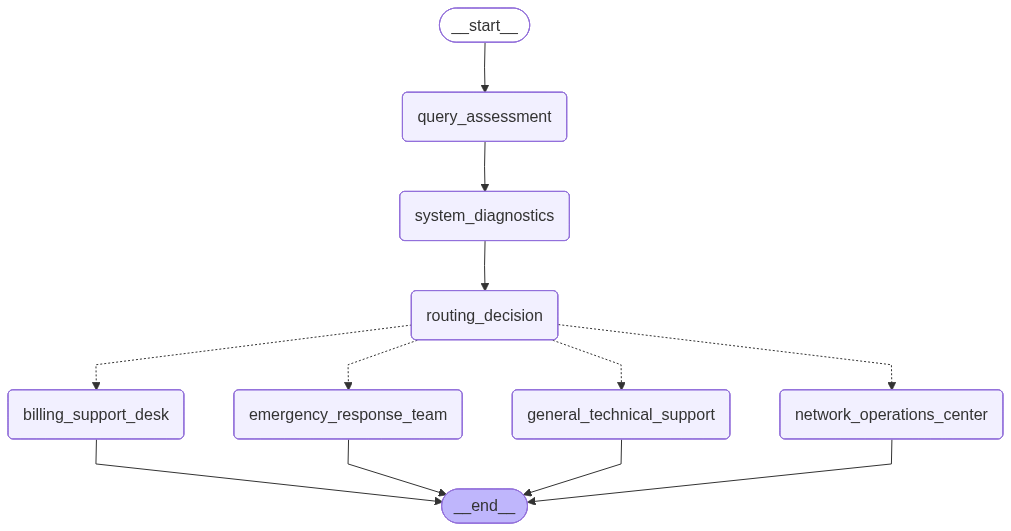

In [17]:
service_desk_system

In [25]:
# Test the Incident System
test_queries = [
    "Internet is extremely slow since morning in the downtown area.",
    "My SIM stopped working after recharge.",
    "Entire area has no signal and I need to make an emergency call."
]

for q in test_queries:
    print(f"\nProcessing Query: {q}")
    result = service_desk_system.invoke({"customer_query": q})
    print(f"Route: {result['assigned_path']}")
    print(f"Resolution: {result['customer_response']}")


Processing Query: Internet is extremely slow since morning in the downtown area.
Route: network_operations_center
Resolution: We're aware of the extremely slow internet speeds affecting the downtown area since this morning. We sincerely apologize for the disruption this has caused. Our Network Operations Center is actively investigating this localized issue with high priority and working diligently to restore full service as quickly as possible. We appreciate your patience and will provide an update once we have more information.

Processing Query: My SIM stopped working after recharge.
Route: network_operations_center
Resolution: Hello! We understand your SIM stopped working after your recent recharge, and we apologize for the inconvenience. Our systems indicate there's currently a network degradation in your region which is affecting service. Our network operations team is already aware and actively working to restore full service as quickly as possible. You do not need to take any 

In [26]:
res = service_desk_system.invoke({
   "customer_query": "Internet is extremely slow since morning in the downtown area."
})
print(f"Route: {res['assigned_path']}")
print(f"Resolution: {res['customer_response']}")

Route: network_operations_center
Resolution: We've received your report regarding extremely slow internet speeds in the downtown area since this morning. We understand how disruptive this can be. Our network teams are already aware of the localized issue affecting services in that specific region and are actively investigating to identify the root cause and restore full performance. No further action is required from your end at this moment. We will provide an update as soon as we have more information or the issue is resolved.


In [27]:
res = service_desk_system.invoke({
   "customer_query": "My SIM stopped working after recharge."
})
print(f"Route: {res['assigned_path']}")
print(f"Resolution: {res['customer_response']}")

Route: network_operations_center
Resolution: Dear customer, we understand your SIM stopped working after your recent recharge, and we sincerely apologize for the inconvenience. Our diagnostics indicate a temporary network degradation in your region is currently affecting your service. Our network operations team is actively working to restore full service as quickly as possible. You do not need to take any action at this time. We appreciate your patience and will notify you once your service is fully restored.


## Advanced Health Assessment & Patient Flow System

This intelligent system leverages AI to automate patient intake, conduct initial health assessments based on reported symptoms, determine the urgency of care, and efficiently route patients to the most appropriate medical professional or department for optimal care coordination.

In [ ]:
import json
from typing import Annotated, List, Union
from typing_extensions import TypedDict

class TriageState(TypedDict):
    patient_input: str
    symptoms: List[str]
    severity: str
    is_emergency: bool
    medical_guidance: str
    triage_summary: str
    route: str
    follow_up_plan: str

In [ ]:
def analyze_symptoms(state: TriageState):
    prompt = f"""
    Analyze: '{state['patient_input']}'
    Extract JSON ONLY (no markdown):
    {{"symptoms": [], "severity": "emergency/moderate/mild", "is_emergency": bool, "dept": "Cardiology/Neurology/Pharmacy/GP"}}
    """
    response = llm.invoke(prompt)
    content = response.content.strip().strip('`').replace('json', '').strip()
    data = json.loads(content)

    return {
        "symptoms": data.get("symptoms", []),
        "severity": data.get("severity", "moderate"),
        "is_emergency": data.get("is_emergency", False),
        "route": data.get("dept", "GP").lower().replace(' ', '_')
    }

In [ ]:
def retrieve_medical_context(state: TriageState):
    symptoms_str = ", ".join(state['symptoms'])
    prompt = f"List 3 diagnostic tests and 1 brief guideline for: {symptoms_str}. Max 50 words."
    response = llm.invoke(prompt)
    return {"medical_guidance": response.content}

In [ ]:
def emergency_agent(state: TriageState):
    return {
        "triage_summary": "EMERGENCY: Immediate clinical intervention required.",
        "follow_up_plan": "Prep ER, notify on-call specialist."
    }

def specialist_agent(state: TriageState):
    prompt = f"""
    Task: Concise Triage Summary for {state['route']}.
    Input: {state['severity']} symptoms: {state['symptoms']}.
    Context: {state['medical_guidance']}
    Output: 2 sentences summary + 1 bullet for follow-up.
    """
    response = llm.invoke(prompt)
    return {"triage_summary": response.content, "follow_up_plan": "Schedule clinic visit."}

In [ ]:
def healthcare_router(state: TriageState):
    if state['is_emergency'] or state['severity'] == "emergency":
        return "emergency_desk"
    return "general_physician" if state['route'] == "gp" else state['route']

In [ ]:
clinical_graph = StateGraph(TriageState)
clinical_graph.add_node("analyze", analyze_symptoms)
clinical_graph.add_node("retrieve", retrieve_medical_context)
clinical_graph.add_node("emergency_desk", emergency_agent)
clinical_graph.add_node("cardiology", specialist_agent)
clinical_graph.add_node("neurology", specialist_agent)
clinical_graph.add_node("pharmacy", specialist_agent)
clinical_graph.add_node("general_physician", specialist_agent)

clinical_graph.set_entry_point("analyze")
clinical_graph.add_edge("analyze", "retrieve")

clinical_graph.add_conditional_edges(
    "retrieve",
    healthcare_router,
    {
        "emergency_desk": "emergency_desk",
        "cardiology": "cardiology",
        "neurology": "neurology",
        "pharmacy": "pharmacy",
        "general_physician": "general_physician"
    }
)

clinical_graph.add_edge("emergency_desk", END)
clinical_graph.add_edge("cardiology", END)
clinical_graph.add_edge("neurology", END)
clinical_graph.add_edge("pharmacy", END)
clinical_graph.add_edge("general_physician", END)

clinical_triage_system = clinical_graph.compile()

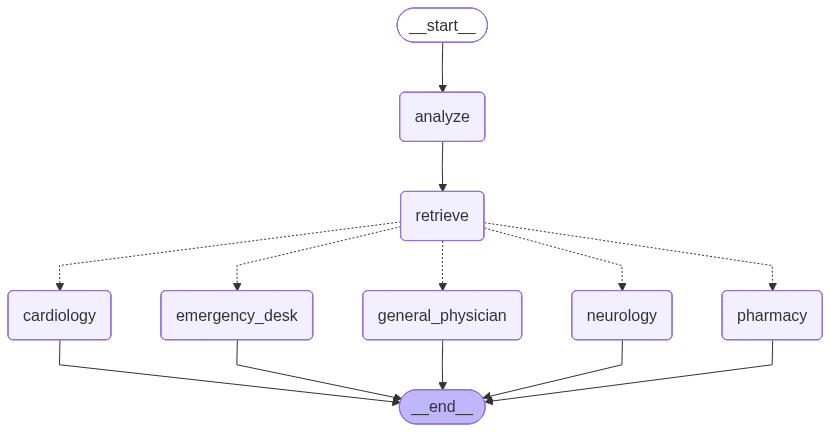

In [ ]:
clinical_triage_system

In [ ]:
case_input = "Chest pain and shortness of breath for the last 30 minutes."
result = clinical_triage_system.invoke({"patient_input": case_input})

print(f"Symptoms Identified: {result['symptoms']}")
print(f"Severity: {result['severity']}")
print(f"Route: {result['route']}")
print("\nTriage Summary:")
print(result['triage_summary'])
print("\nFollow-up Plan")
print(result['follow_up_plan'])


Symptoms Identified: ['Chest pain', 'Shortness of breath']
Severity: emergency
Route: cardiology

Triage Summary:
EMERGENCY: Immediate clinical intervention required.

Follow-up Plan
Prep ER, notify on-call specialist.


In [ ]:
case_input_2 = "Sudden dizziness and blurred vision for the past hour."
result_2 = clinical_triage_system.invoke({"patient_input": case_input_2})

print(f"Symptoms Identified: {result_2['symptoms']}")
print(f"Severity: {result_2['severity']}")
print(f"Route: {result_2['route']}")
print("\nTriage Summary:")
print(result_2['triage_summary'])
print("\nFollow-up Plan:")
print(result_2['follow_up_plan'])


Symptoms Identified: ['sudden dizziness', 'blurred vision']
Severity: emergency
Route: neurology

Triage Summary:
EMERGENCY: Immediate clinical intervention required.

Follow-up Plan:
Prep ER, notify on-call specialist.


In [ ]:
case_input_3 = "Fever and headache for 3 days."
result_3 = clinical_triage_system.invoke({"patient_input": case_input_3})

print(f"Symptoms Identified: {result_3['symptoms']}")
print(f"Severity: {result_3['severity']}")
print(f"Route: {result_3['route']}")
print("\nTriage Summary:")
print(result_3['triage_summary'])
print("\nFollow-up Plan:")
print(result_3['follow_up_plan'])


Symptoms Identified: ['fever', 'headache']
Severity: moderate
Route: gp

Triage Summary:
Patient presents with moderate fever and headache, typically managed with hydration, rest, and over-the-counter pain relief. Monitor symptoms closely, as high/persistent fever or sudden/severe headache changes warrant further medical evaluation.

*   Seek immediate care if fever becomes high/persistent, or headache changes suddenly/severely.

Follow-up Plan:
Schedule clinic visit.


In [ ]:
case_input_4 = "Mild skin rash after taking new medication yesterday."
result_4 = clinical_triage_system.invoke({"patient_input": case_input_4})

print(f"Symptoms Identified: {result_4['symptoms']}")
print(f"Severity: {result_4['severity']}")
print(f"Route: {result_4['route']}")
print("\nTriage Summary:")
print(result_4['triage_summary'])
print("\nFollow-up Plan:")
print(result_4['follow_up_plan'])


Symptoms Identified: ['skin rash']
Severity: mild
Route: gp

Triage Summary:
A mild skin rash is a common presentation, often self-limiting or manageable with basic care. However, its persistence, worsening, or association with systemic symptoms necessitates further evaluation to identify the underlying cause.

*   Referral to dermatology or consideration of diagnostic tests (e.g., skin biopsy, swab for culture, blood tests) if the rash is concerning or fails to improve.

Follow-up Plan:
Schedule clinic visit.


## Finance Domain: Intelligent Loan Risk Assessment & Approval System
Automates loan processing by analyzing income, creditworthiness, and fraud risk to orchestrate approval decisions.

In [ ]:
import json
from typing import Annotated, List, Union
from typing_extensions import TypedDict

class LoanState(TypedDict):
    applicant_data: str
    profile: dict
    credit_score: int
    fraud_risk: str
    debt_to_income: float
    decision_route: str
    rationale: str
    recommendation: dict

In [ ]:
def analyze_applicant(state: LoanState):
    prompt = f"""
    Analyze Applicant Data: '{state['applicant_data']}'
    Extract JSON:
    {{"income": float, "employment": "string", "score_hint": int, "missing_docs": [], "spending_pattern": "stable/unstable"}}
    """
    response = llm.invoke(prompt)
    data = json.loads(response.content.strip().strip('`').replace('json', '').strip())
    return {"profile": data, "credit_score": data.get("score_hint", 0)}

In [ ]:
def verify_credit_and_fraud(state: LoanState):
    profile = state['profile']
    credit = state['credit_score']

    fraud_status = "low"
    if profile.get("spending_pattern") == "unstable" or credit < 500:
        fraud_status = "medium"

    dti = 0.35 if profile.get("income", 0) > 5000 else 0.55

    return {"fraud_risk": fraud_status, "debt_to_income": dti}

In [ ]:
def fast_track_agent(state: LoanState):
    return {"rationale": "Excellent credit and low risk.", "recommendation": {"status": "Approved", "amount": "Requested", "interest": "4.5%"}}

def manual_review_agent(state: LoanState):
    return {"rationale": "Medium risk or DTI concerns.", "recommendation": {"status": "Pending", "amount": "Reduced", "interest": "7.5%"}}

def rejection_agent(state: LoanState):
    return {"rationale": "High risk of fraud or poor credit.", "recommendation": {"status": "Rejected", "amount": 0, "interest": "N/A"}}

def loan_router(state: LoanState):
    if state['fraud_risk'] == "high" or state['credit_score'] < 400:
        return "reject"
    if state['credit_score'] > 750 and state['debt_to_income'] < 0.4:
        return "fast_track"
    return "manual_review"

In [ ]:
loan_graph = StateGraph(LoanState)

loan_graph.add_node("analyze", analyze_applicant)
loan_graph.add_node("verify", verify_credit_and_fraud)
loan_graph.add_node("fast_track", fast_track_agent)
loan_graph.add_node("manual_review", manual_review_agent)
loan_graph.add_node("reject", rejection_agent)

loan_graph.set_entry_point("analyze")
loan_graph.add_edge("analyze", "verify")

loan_graph.add_conditional_edges(
    "verify",
    loan_router,
    {
        "fast_track": "fast_track",
        "manual_review": "manual_review",
        "reject": "reject"
    }
)

loan_graph.add_edge("fast_track", END)
loan_graph.add_edge("manual_review", END)
loan_graph.add_edge("reject", END)

loan_system = loan_graph.compile()

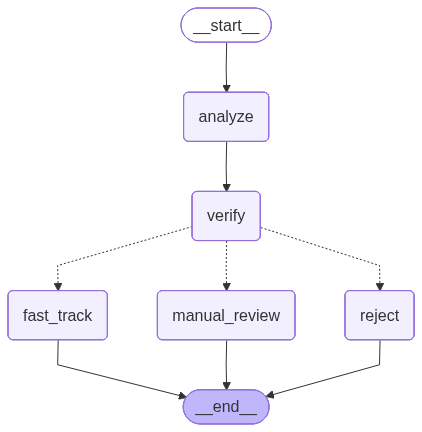

In [ ]:
loan_system

In [ ]:
applicant_input = "Name: Ramesh, Salary: 30000Rs/mo, Credit Score: 800, Debt: 10000, All documents submitted."
loan_result = loan_system.invoke({"applicant_data": applicant_input})

print(f"Credit Score: {loan_result['credit_score']}")
print(f"Risk Level: {loan_result['fraud_risk']}")
print(f"Decision: {loan_result['recommendation']['status']}")
print(f"Rationale: {loan_result['rationale']}")
print(f"Terms: {loan_result['recommendation']}")

Credit Score: 800
Risk Level: low
Decision: Approved
Rationale: Excellent credit and low risk.
Terms: {'status': 'Approved', 'amount': 'Requested', 'interest': '4.5%'}


In [ ]:
applicant_input_2 = "Name: Priya, Salary: 4500Rs/mo, Credit Score: 620, Debt: 2000, missing income certificate."
loan_result_2 = loan_system.invoke({"applicant_data": applicant_input_2})

print(f"Credit Score: {loan_result_2['credit_score']}")
print(f"Risk Level: {loan_result_2['fraud_risk']}")
print(f"Decision: {loan_result_2['recommendation']['status']}")
print(f"Rationale: {loan_result_2['rationale']}")
print(f"Terms: {loan_result_2['recommendation']}")

Credit Score: 620
Risk Level: low
Decision: Pending
Rationale: Medium risk or DTI concerns.
Terms: {'status': 'Pending', 'amount': 'Reduced', 'interest': '7.5%'}


In [ ]:
applicant_input_3 = "Name: Sam, Salary: 2000Rs/mo, Credit Score: 350, Debt: 15000, high credit utilization."
loan_result_3 = loan_system.invoke({"applicant_data": applicant_input_3})

print(f"Credit Score: {loan_result_3['credit_score']}")
print(f"Risk Level: {loan_result_3['fraud_risk']}")
print(f"Decision: {loan_result_3['recommendation']['status']}")
print(f"Rationale: {loan_result_3['rationale']}")

Credit Score: 350
Risk Level: medium
Decision: Rejected
Rationale: High risk of fraud or poor credit.


In [ ]:
applicant_input_4 = "Name: Ajay, Salary: 10000Rs/mo, Credit Score: 700, Debt: 1000, frequent gambling transactions and unstable spending."
loan_result_4 = loan_system.invoke({"applicant_data": applicant_input_4})

print(f"Spending Pattern: {loan_result_4['profile'].get('spending_pattern')}")
print(f"Risk Level: {loan_result_4['fraud_risk']}")
print(f"Decision: {loan_result_4['recommendation']['status']}")
print(f"Rationale: {loan_result_4['rationale']}")

Spending Pattern: unstable
Risk Level: medium
Decision: Pending
Rationale: Medium risk or DTI concerns.
